Original Image Size   : 1554432 bits
Compressed Image Size : 1468439 bits
Compression Ratio     : 1.06
Compression Percentage: 5.53 %


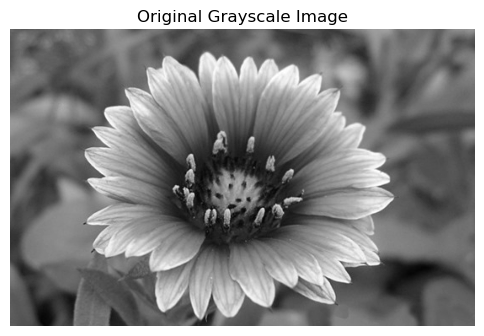


Huffman Codes:
8 : 100011111101111100
9 : 100011111101111101
10 : 10001111110111111
11 : 1000111111011110
12 : 100011111101110
13 : 10001111110110
14 : 010100110110
15 : 101011010100
16 : 00110011110
17 : 10011101011
18 : 10011101010
19 : 11011000000
20 : 0000000010
21 : 0010100011
22 : 0000000011
23 : 0011001110
24 : 0101001100
25 : 1000100000
26 : 1000111110
27 : 1001110100


In [1]:
import cv2
import heapq
from collections import Counter
import matplotlib.pyplot as plt

# Read image in grayscale
image = cv2.imread("input.jpg", cv2.IMREAD_GRAYSCALE)

# Check whether image was loaded
if image is None:
    print("Error: Image not found.")
else:
    # Flatten image into 1D array
    pixels = image.flatten()

    # Calculate frequency of each pixel intensity
    frequency = Counter(pixels)

    # Node for Huffman tree
    class Node:
        def __init__(self, symbol=None, freq=0, left=None, right=None):
            self.symbol = symbol
            self.freq = freq
            self.left = left
            self.right = right

        def __lt__(self, other):
            return self.freq < other.freq

    # Create priority queue
    heap = []

    for symbol, freq in frequency.items():
        heapq.heappush(heap, Node(symbol, freq))

    # Build Huffman tree
    while len(heap) > 1:
        left = heapq.heappop(heap)
        right = heapq.heappop(heap)

        merged = Node(
            freq=left.freq + right.freq,
            left=left,
            right=right
        )

        heapq.heappush(heap, merged)

    root = heap[0]

    # Generate Huffman codes
    huffman_codes = {}

    def generate_codes(node, code=""):
        if node is None:
            return

        if node.symbol is not None:
            huffman_codes[node.symbol] = code if code else "0"
            return

        generate_codes(node.left, code + "0")
        generate_codes(node.right, code + "1")

    generate_codes(root)

    # Encode image
    encoded_data = "".join(
        huffman_codes[pixel] for pixel in pixels
    )

    # Calculate sizes
    original_bits = len(pixels) * 8
    compressed_bits = len(encoded_data)

    compression_ratio = original_bits / compressed_bits
    compression_percentage = (
        1 - compressed_bits / original_bits
    ) * 100

    print("Original Image Size   :", original_bits, "bits")
    print("Compressed Image Size :", compressed_bits, "bits")
    print("Compression Ratio     :", round(compression_ratio, 2))
    print("Compression Percentage:", round(compression_percentage, 2), "%")

    # Display image
    plt.figure(figsize=(6, 6))
    plt.imshow(image, cmap="gray")
    plt.title("Original Grayscale Image")
    plt.axis("off")
    plt.show()

    # Display some Huffman codes
    print("\nHuffman Codes:")
    for symbol, code in sorted(huffman_codes.items())[:20]:
        print(symbol, ":", code)

In [2]:
import cv2
import heapq
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter
from ipywidgets import FileUpload, Button, Output
from IPython.display import display, clear_output

In [3]:
upload = FileUpload(
    accept='image/*',
    multiple=False
)

display(upload)

FileUpload(value={}, accept='image/*', description='Upload')

In [2]:
def huffman_compression(image):

    # Flatten image into 1D array
    pixels = image.flatten()

    # Calculate frequency of each pixel intensity
    frequency = Counter(int(pixel) for pixel in pixels)

    # Huffman tree node
    class Node:
        def __init__(self, symbol=None, freq=0, left=None, right=None):
            self.symbol = symbol
            self.freq = freq
            self.left = left
            self.right = right

        def __lt__(self, other):
            return self.freq < other.freq

    # Create priority queue
    heap = []

    for symbol, freq in frequency.items():
        heapq.heappush(heap, Node(symbol, freq))

    # Check whether image contains only one intensity
    single_symbol = len(heap) == 1

    # Build Huffman tree
    if single_symbol:
        root = heap[0]
        codes = {root.symbol: "0"}

    else:
        while len(heap) > 1:
            left = heapq.heappop(heap)
            right = heapq.heappop(heap)

            merged = Node(
                freq=left.freq + right.freq,
                left=left,
                right=right
            )

            heapq.heappush(heap, merged)

        root = heap[0]

        # Generate Huffman codes
        codes = {}

        def generate_codes(node, code=""):
            if node.symbol is not None:
                codes[node.symbol] = code
                return

            generate_codes(node.left, code + "0")
            generate_codes(node.right, code + "1")

        generate_codes(root)

    # Encode image
    encoded = ''.join(
        codes[int(pixel)]
        for pixel in pixels
    )

    # Decode image
    decoded_pixels = []

    if single_symbol:
        decoded_pixels = [root.symbol] * len(pixels)

    else:
        node = root

        for bit in encoded:

            if bit == '0':
                node = node.left
            else:
                node = node.right

            if node.symbol is not None:
                decoded_pixels.append(node.symbol)
                node = root

    # Reconstruct image
    reconstructed = np.array(
        decoded_pixels,
        dtype=np.uint8
    ).reshape(image.shape)

    return frequency, codes, encoded, reconstructed

In [7]:
if len(upload.value) == 0:
    print("Please upload an image first.")

else:

    file_info = next(iter(upload.value.values()))

    image_bytes = file_info['content']

    image_array = np.frombuffer(
        image_bytes,
        dtype=np.uint8
    )

    image = cv2.imdecode(
        image_array,
        cv2.IMREAD_GRAYSCALE
    )

    if image is None:
        print("Unable to read the image.")

    else:

        frequency, codes, encoded, reconstructed = \
            huffman_compression(image)

        original_bits = image.size * 8
        compressed_bits = len(encoded)

        compression_ratio = (
            original_bits / compressed_bits
        )

        space_saving = (
            1 - compressed_bits / original_bits
        ) * 100

        print("=" * 60)
        print("        HUFFMAN IMAGE COMPRESSION")
        print("=" * 60)

        print("\nImage Information")
        print("-" * 60)
        print("Image Dimensions  :", image.shape[1], "x", image.shape[0])
        print("Total Pixels      :", image.size)
        print("Unique Intensities :", len(frequency))

        print("\nCompression Results")
        print("-" * 60)
        print("Original Size     :", original_bits, "bits")
        print("Compressed Size   :", compressed_bits, "bits")
        print("Compression Ratio :", round(compression_ratio, 3))
        print("Space Saving      :", round(space_saving, 2), "%")

        print("\nHuffman Codes")
        print("-" * 60)

        for intensity in sorted(codes.keys()):
            print(
                f"Intensity {intensity:3d} : {codes[intensity]}"
            )

        HUFFMAN IMAGE COMPRESSION

Image Information
------------------------------------------------------------
Image Dimensions  : 552 x 352
Total Pixels      : 194304
Unique Intensities : 248

Compression Results
------------------------------------------------------------
Original Size     : 1554432 bits
Compressed Size   : 1468439 bits
Compression Ratio : 1.059
Space Saving      : 5.53 %

Huffman Codes
------------------------------------------------------------
Intensity   8 : 100011111101111100
Intensity   9 : 100011111101111101
Intensity  10 : 10001111110111111
Intensity  11 : 1000111111011110
Intensity  12 : 100011111101110
Intensity  13 : 10001111110110
Intensity  14 : 010100110110
Intensity  15 : 101011010100
Intensity  16 : 00110011110
Intensity  17 : 10011101011
Intensity  18 : 10011101010
Intensity  19 : 11011000000
Intensity  20 : 0000000010
Intensity  21 : 0010100011
Intensity  22 : 0000000011
Intensity  23 : 0011001110
Intensity  24 : 0101001100
Intensity  25 : 100010

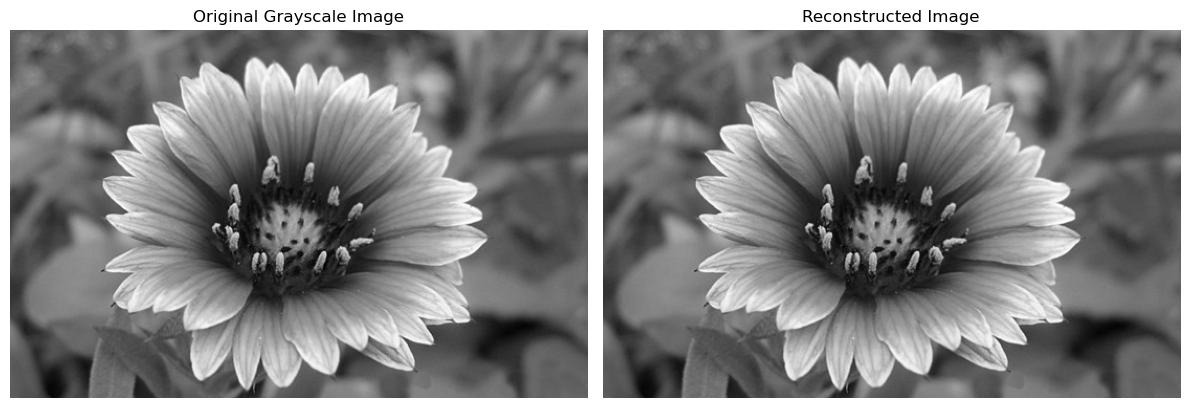

In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(reconstructed, cmap="gray")
plt.title("Reconstructed Image")
plt.axis("off")

plt.tight_layout()
plt.show()

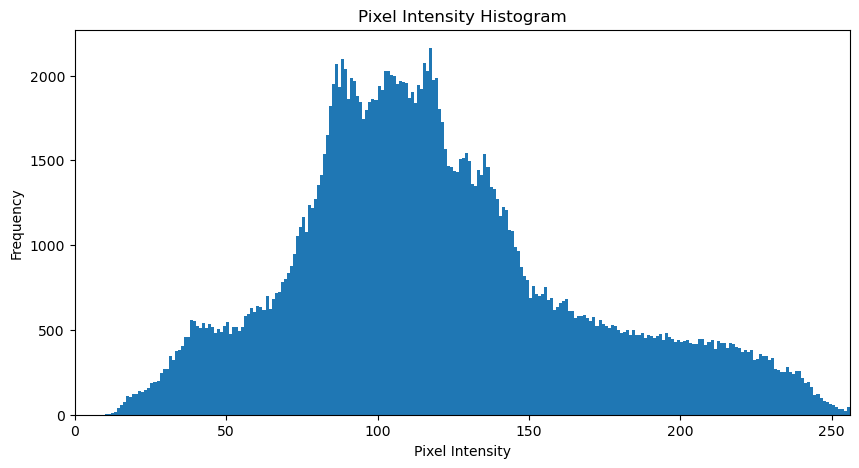

In [9]:
plt.figure(figsize=(10, 5))

plt.hist(
    image.ravel(),
    bins=256,
    range=(0, 256)
)

plt.title("Pixel Intensity Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.xlim(0, 256)

plt.show()

In [10]:
sorted_frequency = sorted(
    frequency.items(),
    key=lambda x: x[1],
    reverse=True
)

print("Most Frequent Pixel Intensities")
print("-" * 55)
print("Intensity\tFrequency\tHuffman Code")
print("-" * 55)

for intensity, freq in sorted_frequency[:20]:
    print(
        f"{intensity:3d}\t\t"
        f"{freq:7d}\t\t"
        f"{codes[intensity]}"
    )

Most Frequent Pixel Intensities
-------------------------------------------------------
Intensity	Frequency	Huffman Code
-------------------------------------------------------
117		   2162		001000
 88		   2098		000100
115		   2076		000010
 86		   2066		000001
 89		   2039		1111110
102		   2028		1111101
103		   2026		1111100
116		   2026		1111011
104		   2005		1111010
105		   2000		1111000
 91		   1986		1110111
119		   1983		1110110
118		   1974		1110100
 92		   1968		1110011
107		   1966		1110010
108		   1961		1110001
109		   1956		1110000
106		   1953		1101111
 85		   1950		1101110
113		   1945		1101101


In [11]:
if np.array_equal(image, reconstructed):
    print("✓ Reconstruction Successful")
    print("✓ Original and reconstructed images are identical.")
    print("✓ Huffman decoding is lossless.")
else:
    print("✗ Reconstruction failed.")

✓ Reconstruction Successful
✓ Original and reconstructed images are identical.
✓ Huffman decoding is lossless.


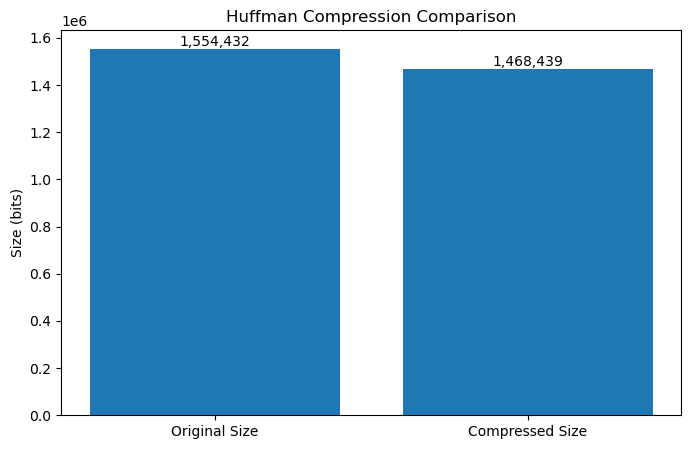

Compression Ratio : 1.059
Space Saving      : 5.53 %


In [12]:
labels = [
    "Original Size",
    "Compressed Size"
]

sizes = [
    original_bits,
    compressed_bits
]

plt.figure(figsize=(8, 5))

plt.bar(labels, sizes)

plt.title("Huffman Compression Comparison")
plt.ylabel("Size (bits)")

for i, value in enumerate(sizes):
    plt.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.show()

print("Compression Ratio :", round(compression_ratio, 3))
print("Space Saving      :", round(space_saving, 2), "%")

In [13]:
print("=" * 60)
print("             HUFFMAN IMAGE COMPRESSION")
print("=" * 60)

print(f"Image Size          : {image.shape[1]} x {image.shape[0]}")
print(f"Total Pixels        : {image.size:,}")
print(f"Unique Intensities  : {len(frequency)}")

print("-" * 60)

print(f"Original Size       : {original_bits:,} bits")
print(f"Compressed Size     : {compressed_bits:,} bits")
print(f"Compression Ratio   : {compression_ratio:.3f}")
print(f"Space Saving        : {space_saving:.2f}%")

print("-" * 60)

if np.array_equal(image, reconstructed):
    print("Reconstruction      : SUCCESSFUL")
    print("Compression Type    : LOSSLESS")
else:
    print("Reconstruction      : FAILED")

print("=" * 60)

             HUFFMAN IMAGE COMPRESSION
Image Size          : 552 x 352
Total Pixels        : 194,304
Unique Intensities  : 248
------------------------------------------------------------
Original Size       : 1,554,432 bits
Compressed Size     : 1,468,439 bits
Compression Ratio   : 1.059
Space Saving        : 5.53%
------------------------------------------------------------
Reconstruction      : SUCCESSFUL
Compression Type    : LOSSLESS


In [14]:
import os

# Add padding so the bitstream becomes a multiple of 8
padding = (8 - len(encoded) % 8) % 8

padded_encoded = encoded + ("0" * padding)

# Convert binary string to bytes
compressed_bytes = bytearray()

for i in range(0, len(padded_encoded), 8):
    byte = padded_encoded[i:i+8]
    compressed_bytes.append(int(byte, 2))

# Save compressed data
compressed_filename = "huffman_compressed.bin"

with open(compressed_filename, "wb") as f:
    f.write(compressed_bytes)

# Get actual file size
actual_size = os.path.getsize(compressed_filename)

print("=" * 60)
print("       HUFFMAN COMPRESSED FILE")
print("=" * 60)

print("File Name          :", compressed_filename)
print("Compressed Size    :", actual_size, "bytes")
print("Compressed Size    :", actual_size * 8, "bits")
print("Padding Bits       :", padding)
print("Compression Ratio  :", round(
    (image.size * 8) / (actual_size * 8), 3
))

print("=" * 60)

       HUFFMAN COMPRESSED FILE
File Name          : huffman_compressed.bin
Compressed Size    : 183555 bytes
Compressed Size    : 1468440 bits
Padding Bits       : 1
Compression Ratio  : 1.059


In [15]:
# Read compressed binary file

with open(compressed_filename, "rb") as f:
    compressed_data = f.read()

# Convert bytes back to binary string
binary_data = ""

for byte in compressed_data:
    binary_data += format(byte, "08b")

# Remove padding bits
if padding > 0:
    binary_data = binary_data[:-padding]

# Decode using Huffman tree
decoded_pixels = []

node = root

if len(frequency) == 1:
    decoded_pixels = [root.symbol] * image.size

else:
    for bit in binary_data:

        if bit == "0":
            node = node.left
        else:
            node = node.right

        if node.symbol is not None:
            decoded_pixels.append(node.symbol)
            node = root

# Convert decoded pixels into image
decoded_image = np.array(
    decoded_pixels,
    dtype=np.uint8
).reshape(image.shape)

print("Compressed file read successfully.")
print("Decoded pixels:", len(decoded_pixels))
print("Decoded image shape:", decoded_image.shape)

Compressed file read successfully.
Decoded pixels: 194304
Decoded image shape: (352, 552)


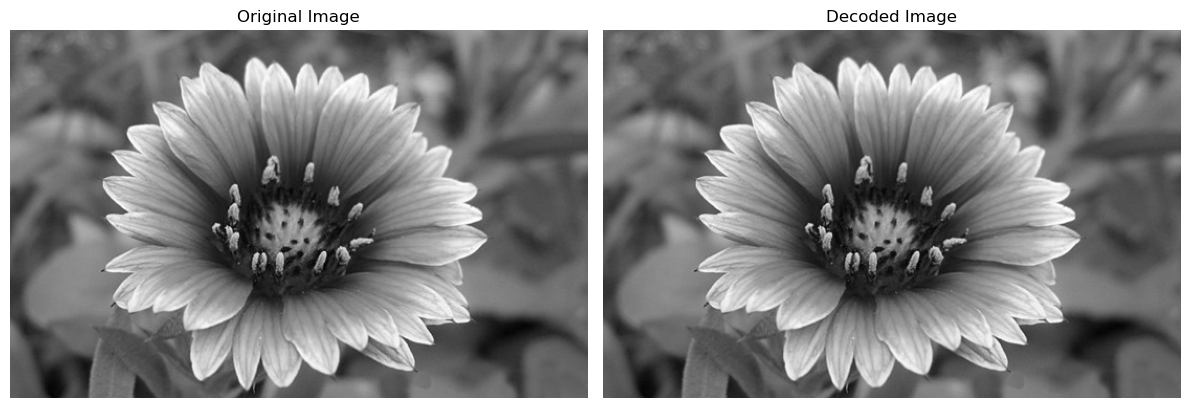

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(decoded_image, cmap="gray")
plt.title("Decoded Image")
plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
if np.array_equal(image, decoded_image):
    print("✓ SUCCESS")
    print("✓ Original and decoded images are identical.")
    print("✓ Huffman compression and decompression completed successfully.")
    print("✓ Compression is LOSSLESS.")
else:
    print("✗ ERROR")
    print("✗ Decoded image is different from the original.")

✓ SUCCESS
✓ Original and decoded images are identical.
✓ Huffman compression and decompression completed successfully.
✓ Compression is LOSSLESS.


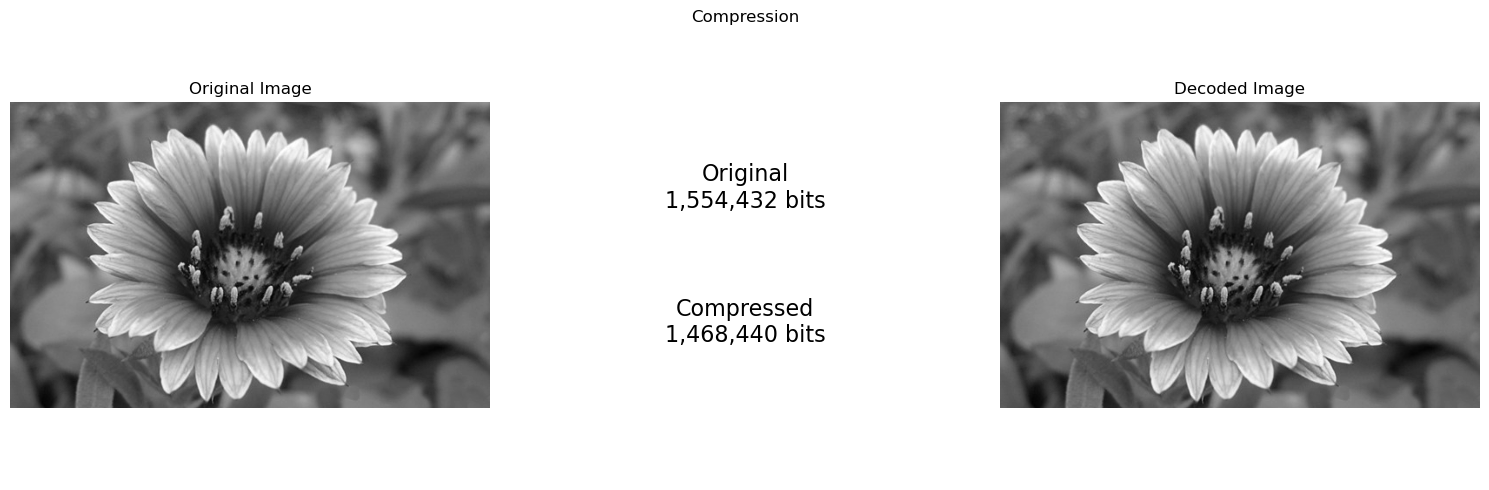

FINAL COMPRESSION RESULT
Original Size     : 1,554,432 bits
Compressed File   : 183,555 bytes
Compressed Size   : 1,468,440 bits
Compression Ratio : 1.059
Space Saved       : 5.53%


In [18]:
import os
import matplotlib.pyplot as plt

original_file_size = image.size
compressed_file_size = os.path.getsize(compressed_filename)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.text(
    0.5,
    0.65,
    f"Original\n{original_bits:,} bits",
    ha="center",
    va="center",
    fontsize=16
)

plt.text(
    0.5,
    0.35,
    f"Compressed\n{compressed_file_size * 8:,} bits",
    ha="center",
    va="center",
    fontsize=16
)

plt.title("Compression")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(decoded_image, cmap="gray")
plt.title("Decoded Image")
plt.axis("off")

plt.tight_layout()
plt.show()

print("=" * 60)
print("FINAL COMPRESSION RESULT")
print("=" * 60)
print(f"Original Size     : {original_bits:,} bits")
print(f"Compressed File   : {compressed_file_size:,} bytes")
print(f"Compressed Size   : {compressed_file_size * 8:,} bits")
print(f"Compression Ratio : {original_bits / (compressed_file_size * 8):.3f}")
print(f"Space Saved       : {(1 - (compressed_file_size * 8) / original_bits) * 100:.2f}%")
print("=" * 60)

In [19]:
import pickle

# Store everything required for decompression
huffman_package = {
    "codes": codes,
    "encoded_data": encoded,
    "shape": image.shape
}

# Save complete compressed package
with open("huffman_image.huff", "wb") as f:
    pickle.dump(huffman_package, f)

file_size = os.path.getsize("huffman_image.huff")

print("=" * 60)
print("     COMPLETE HUFFMAN COMPRESSED FILE")
print("=" * 60)

print("File Name       : huffman_image.huff")
print("File Size       :", file_size, "bytes")
print("Image Shape     :", image.shape)
print("Huffman Symbols :", len(codes))
print("=" * 60)

     COMPLETE HUFFMAN COMPRESSED FILE
File Name       : huffman_image.huff
File Size       : 1471882 bytes
Image Shape     : (352, 552)
Huffman Symbols : 248


In [20]:
with open("huffman_image.huff", "rb") as f:
    loaded_package = pickle.load(f)

loaded_codes = loaded_package["codes"]
loaded_encoded = loaded_package["encoded_data"]
loaded_shape = loaded_package["shape"]

print("Compressed file loaded successfully.")
print("Image Shape:", loaded_shape)
print("Number of Huffman Codes:", len(loaded_codes))

Compressed file loaded successfully.
Image Shape: (352, 552)
Number of Huffman Codes: 248


In [21]:
# Create reverse Huffman dictionary
reverse_codes = {
    code: symbol
    for symbol, code in loaded_codes.items()
}

# Decode the bitstream
current_code = ""
decoded_pixels = []

for bit in loaded_encoded:
    current_code += bit

    if current_code in reverse_codes:
        decoded_pixels.append(
            reverse_codes[current_code]
        )
        current_code = ""

# Reconstruct image
final_image = np.array(
    decoded_pixels,
    dtype=np.uint8
).reshape(loaded_shape)

print("Decompression completed.")
print("Decoded Pixels:", len(decoded_pixels))

Decompression completed.
Decoded Pixels: 194304


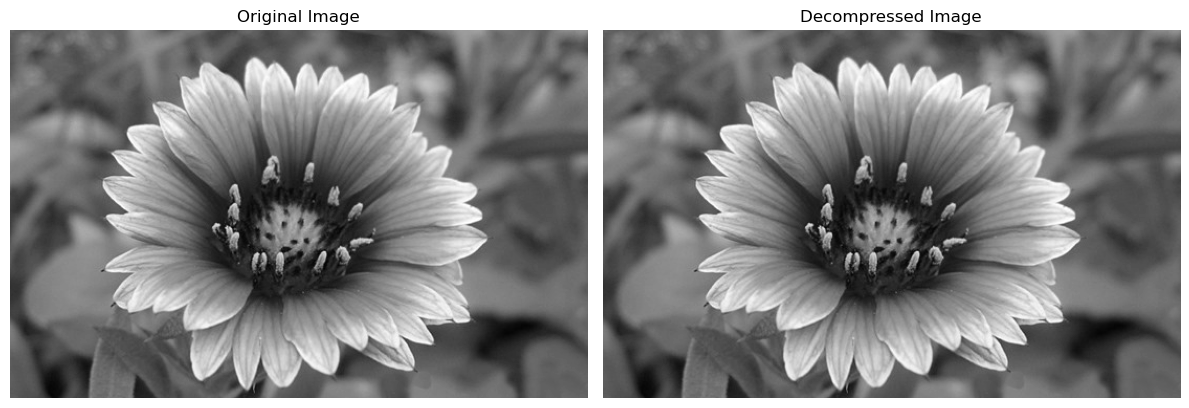


✓ SUCCESS
✓ Original and decompressed images are identical.
✓ Huffman compression is lossless.


In [22]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(final_image, cmap="gray")
plt.title("Decompressed Image")
plt.axis("off")

plt.tight_layout()
plt.show()

if np.array_equal(image, final_image):
    print("\n✓ SUCCESS")
    print("✓ Original and decompressed images are identical.")
    print("✓ Huffman compression is lossless.")
else:
    print("\n✗ Decompression failed.")

In [23]:
import os

# Original raw grayscale image size
original_size = image.nbytes

# Actual Huffman compressed file size
compressed_size = os.path.getsize("huffman_image.huff")

# Compression calculations
compression_ratio = original_size / compressed_size

space_saved = (
    (original_size - compressed_size)
    / original_size
) * 100

print("=" * 65)
print("             HUFFMAN COMPRESSION ANALYSIS")
print("=" * 65)

print(f"Original Image Size     : {original_size:,} bytes")
print(f"Compressed File Size    : {compressed_size:,} bytes")
print(f"Compression Ratio       : {compression_ratio:.3f}:1")
print(f"Space Saved             : {space_saved:.2f}%")

print("-" * 65)

if np.array_equal(image, final_image):
    print("Decompression Status    : SUCCESSFUL")
    print("Compression Type        : LOSSLESS")
else:
    print("Decompression Status    : FAILED")

print("=" * 65)

             HUFFMAN COMPRESSION ANALYSIS
Original Image Size     : 194,304 bytes
Compressed File Size    : 1,471,882 bytes
Compression Ratio       : 0.132:1
Space Saved             : -657.52%
-----------------------------------------------------------------
Decompression Status    : SUCCESSFUL
Compression Type        : LOSSLESS


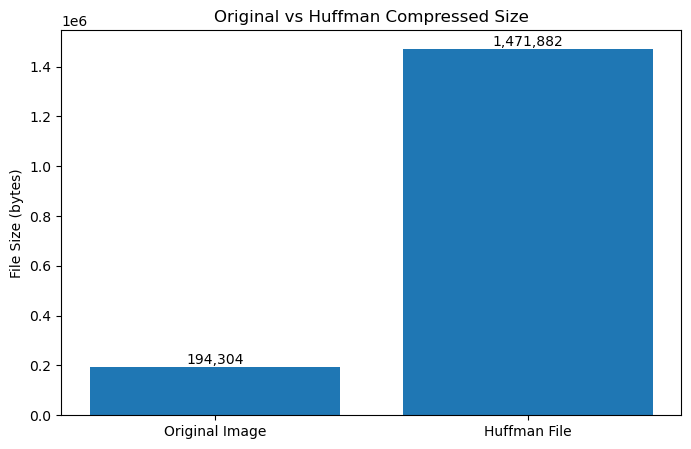

In [24]:
sizes = [
    original_size,
    compressed_size
]

labels = [
    "Original Image",
    "Huffman File"
]

plt.figure(figsize=(8, 5))

bars = plt.bar(labels, sizes)

plt.title("Original vs Huffman Compressed Size")
plt.ylabel("File Size (bytes)")

for bar, size in zip(bars, sizes):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{size:,}",
        ha="center",
        va="bottom"
    )

plt.show()

In [25]:
output_filename = "huffman_decompressed.png"

cv2.imwrite(
    output_filename,
    final_image
)

print("Decompressed image saved as:")
print(output_filename)

print("\nOriginal image shape   :", image.shape)
print("Decompressed shape     :", final_image.shape)

if np.array_equal(image, final_image):
    print("✓ Pixel-by-pixel verification: PASSED")

Decompressed image saved as:
huffman_decompressed.png

Original image shape   : (352, 552)
Decompressed shape     : (352, 552)
✓ Pixel-by-pixel verification: PASSED
